# Modular SAXS/WAXS Analysis Pipeline
This notebook runs the analysis using modular functions and settings from `sample_settings.csv`.

In [53]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Add root directory to python path for imports
sys.path.append('..')

from classes_and_functions.read_data import DataReader, read_background_directory, read_background_file
from classes_and_functions.electrochemical_data_filtration import process_electrochemical_data
from classes_and_functions.data_correction import DataCorrection
from classes_and_functions.utils import contourplot, subtract_background, combined_contourplot



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Settings and Select Sample

In [33]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# Create form to add new sample
style = {'description_width': 'initial'}
sample_id_input = widgets.Text(description="Sample ID:", style=style)
data_format_input = widgets.Dropdown(options=["Individual", "HDF5"], description="Data Format:", style=style)
data_path_input = widgets.Text(description="Data Path (Folder or .h5 file):", style=style)
mpr_path_input = widgets.Text(description="MPR File Path (if Individual):", style=style)
empty_saxs_input = widgets.Text(description="Empty Cell SAXS Dir (Optional):", style=style)
empty_waxs_input = widgets.Text(description="Empty Cell WAXS Dir (Optional):", style=style)
discharge_rate_input = widgets.FloatText(value=10.0, description="Discharge Rate:", style=style)

save_button = widgets.Button(description="Save Sample", button_style='success')
output = widgets.Output()

def save_sample(b):
    with output:
        output.clear_output()
        if not sample_id_input.value or not data_path_input.value:
            print("Please provide Sample ID and Data Path.")
            return
            
        csv_path = 'sample_settings.csv'
        try:
            df = pd.read_csv(csv_path)
        except FileNotFoundError:
            df = pd.DataFrame(columns=['Sample_ID', 'Data_Format', 'Data_Path', 'MPR_File_Path', 
                                       'Discharge_Rate', 'SAXS_Min_Limit', 'SAXS_Max_Limit', 
                                       'WAXS_Min_Limit', 'WAXS_Max_Limit', 'Empty_Dir_SAXS', 
                                       'Empty_Dir_WAXS', 'Capillary_SAXS', 'Capillary_WAXS'])
        
        if sample_id_input.value in df['Sample_ID'].values:
            print(f"Sample '{sample_id_input.value}' already exists! Update manually or use a new ID.")
            return
            
        new_row = {
            'Sample_ID': sample_id_input.value,
            'Data_Format': data_format_input.value,
            'Data_Path': data_path_input.value,
            'MPR_File_Path': mpr_path_input.value if mpr_path_input.value else None,
            'Discharge_Rate': discharge_rate_input.value,
            'SAXS_Min_Limit': 0.13,  # default
            'SAXS_Max_Limit': 3.0,   # default
            'WAXS_Min_Limit': 22.0,  # default
            'WAXS_Max_Limit': 30.0,  # default
            'Empty_Dir_SAXS': empty_saxs_input.value if empty_saxs_input.value else None,
            'Empty_Dir_WAXS': empty_waxs_input.value if empty_waxs_input.value else None,
            'Capillary_SAXS': None,
            'Capillary_WAXS': None
        }
        
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
        df.to_csv(csv_path, index=False)
        print(f"Successfully added sample: {sample_id_input.value}! Please re-run the dropdown cell below to see it.")

save_button.on_click(save_sample)

form = widgets.VBox([
    widgets.HTML("<h3>Add New Sample to Settings</h3>"),
    sample_id_input, 
    data_format_input, 
    data_path_input, 
    mpr_path_input,
    empty_saxs_input,
    empty_waxs_input,
    discharge_rate_input,
    save_button,
    output
])
display(form)


In [34]:
settings_df = pd.read_csv('sample_settings.csv')
sample_selector = widgets.Dropdown(
    options=settings_df['Sample_ID'].tolist(),
    description='Sample:',
)
display(sample_selector)

Dropdown(description='Sample:', options=('Without_iodine_20251017', 'HDF5_Test_Sample', 'S-Operando-7'), value…

In [35]:
# Get settings for selected sample
sample_settings = settings_df[settings_df['Sample_ID'] == sample_selector.value].iloc[0]
print(f"Selected Sample: {sample_settings['Sample_ID']}")
print(f"Data Format: {sample_settings['Data_Format']}")

Selected Sample: S-Operando-7
Data Format: HDF5


## 2. Read Data

In [36]:
reader = DataReader(
    data_format=sample_settings['Data_Format'],
    data_path=sample_settings['Data_Path'],
    mpr_file_path=sample_settings.get('MPR_File_Path') if pd.notna(sample_settings.get('MPR_File_Path')) else None
)
all_data = reader.read_data()
print(f"Loaded {len(all_data['SAXS'])} SAXS files and {len(all_data['WAXS'])} WAXS files.")

if all_data.get('Electrochemical') is not None:
    print(f"Found Electrochemical data: {len(all_data['Electrochemical'])} rows.")
else:
    print("No Electrochemical data found.")

if all_data.get('Background_SAXS') is not None:
    print("Found SAXS Background data.")
else:
    print("No SAXS Background data found.")
    
if all_data.get('Background_WAXS') is not None:
    print("Found WAXS Background data.")
else:
    print("No WAXS Background data found.")


Loaded 800 SAXS files and 800 WAXS files.
Found Electrochemical data: 54749 rows.
Found SAXS Background data.
Found WAXS Background data.


## 3. Data Correction (Background & Capillary)

In [37]:
# Load Backgrounds into all_data (if using INDIVIDUAL files)
if sample_settings['Data_Format'].lower() == 'individual':
    if pd.notna(sample_settings.get('Empty_Dir_SAXS')):
        empty_saxs_dict = read_background_directory(sample_settings['Empty_Dir_SAXS'], '*_0_*.dat')
        if empty_saxs_dict and len(empty_saxs_dict) > 0:
            all_data['Background_SAXS'] = list(empty_saxs_dict.values())[0]
            print(f"Loaded SAXS background from {sample_settings['Empty_Dir_SAXS']}")
            
    if pd.notna(sample_settings.get('Empty_Dir_WAXS')):
        empty_waxs_dict = read_background_directory(sample_settings['Empty_Dir_WAXS'], '*_1_*.dat')
        if empty_waxs_dict and len(empty_waxs_dict) > 0:
            all_data['Background_WAXS'] = list(empty_waxs_dict.values())[0]
            print(f"Loaded WAXS background from {sample_settings['Empty_Dir_WAXS']}")
else:
    print("Backgrounds already loaded from HDF5.")



Backgrounds already loaded from HDF5.


## 4. Process Electrochemical Data

Indices for cycle change: [961, 8989, 13761, 18524, 23371, 28245, 33400, 38574, 43934, 49296, 54748]

Absolute times for change in electrochemical state:
[np.float64(960.00037574835), np.float64(41087.308564884865), np.float64(64934.49480930378), np.float64(88738.14452216122), np.float64(112961.89139220765), np.float64(137321.7134862882), np.float64(163086.285517456), np.float64(188945.13256337773), np.float64(215730.84815431572), np.float64(242529.77434732346), np.float64(269780.48672656156)]

Corresponding SAXS file numbers:
[3, 105, 166, 226, 288, 350, 415, 481, 549, 617, 686]


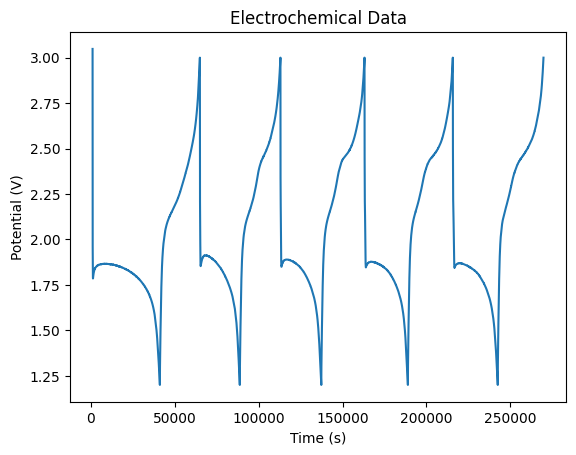

Applied current: 0.17409999668598175
Mass of active material: 1.04 mg


In [38]:
ec_results = process_electrochemical_data(all_data, rate=sample_settings['Discharge_Rate'])

## 5. Generate SAXS Contour Plot

# Perform SAXS Background Correction

Subtracting SAXS background...


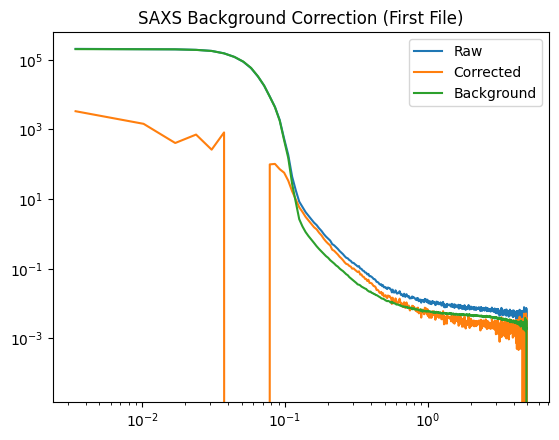

In [39]:

if all_data.get('Background_SAXS') is not None:
    print("Subtracting SAXS background...")
    corrected_saxs = subtract_background(all_data['SAXS'], all_data['Background_SAXS'])
    # Plot an example to verify
    import matplotlib.pyplot as plt
    plt.figure()
    idx = list(corrected_saxs.keys())[0]
    plt.plot(10 * all_data['SAXS'][idx].iloc[:,0], all_data['SAXS'][idx].iloc[:,1], label="Raw")
    plt.plot(10 * corrected_saxs[idx].iloc[:,0], corrected_saxs[idx].iloc[:,1], label="Corrected")
    plt.plot(10 * all_data['Background_SAXS'].iloc[:,0], all_data['Background_SAXS'].iloc[:,1], label="Background")
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.title("SAXS Background Correction (First File)")
    plt.show()
else:
    print("No SAXS background found to subtract.")
    corrected_saxs = all_data['SAXS']



Plotting cycles 1 to 2
Starting SAXS file: 3, Discharge file: 105, Last SAXS file: 288


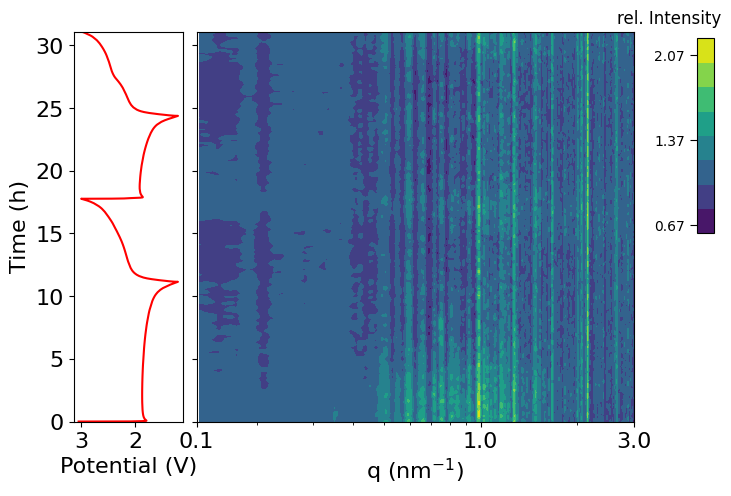

In [46]:
# Select your cycle range here
starting_cycle = 1
end_cycle = 2

# Extract the correct indices based on cycles
start_idx = 2 * starting_cycle - 2
end_idx = 2 * end_cycle

saxs_files = ec_results['saxs_file_numbers']
cycle_indices = ec_results['cycle_change_indices']
elec_df = ec_results['filtered_dataframe']

starting_file = saxs_files[start_idx]
last_file = saxs_files[end_idx]
discharge_file = saxs_files[start_idx + 1]

# Filter electrochemical data for the selected cycles
# Fallback for columns
time_col = 'time/s' if 'time/s' in elec_df.columns else elec_df.columns[2]

elec_df_2 = elec_df.loc[cycle_indices[start_idx]:cycle_indices[end_idx]]

print(f"Plotting cycles {starting_cycle} to {end_cycle}")
print(f"Starting SAXS file: {starting_file}, Discharge file: {discharge_file}, Last SAXS file: {last_file}")

contourplot(
    plot_type='saxs',
    data_normalization='relative',
    Normalization_file=discharge_file, # or starting_file
    data_dictionary=corrected_saxs,
    new_time_dict=all_data['TimeStamps_SAXS'],
    min_limit=sample_settings['SAXS_Min_Limit'],
    max_limit=sample_settings['SAXS_Max_Limit'],
    starting_file=starting_file,
    last_file=last_file,
    elec_df_2=elec_df_2,
    y_axis_mode='time',
    colorbar_position = 'side'
)




## 6. Generate WAXS Contour Plot

Subtracting WAXS background...


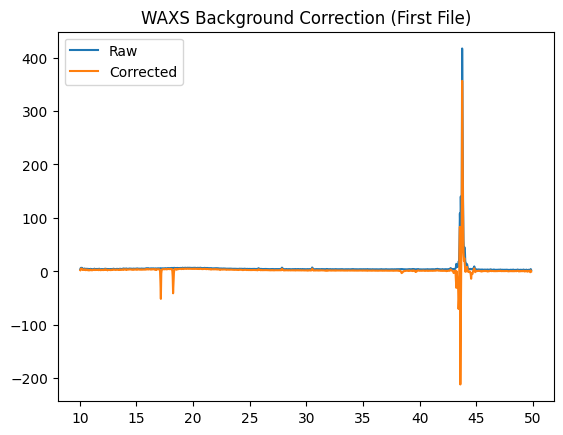

In [42]:
# Perform WAXS Background Correction
if all_data.get('Background_WAXS') is not None:
    print("Subtracting WAXS background...")
    # Using target_X for alignment as per Operando-7
    corrected_waxs = subtract_background(all_data['WAXS'], all_data['Background_WAXS'], align_target_X=3.4)
    # Plot an example to verify
    import matplotlib.pyplot as plt
    import numpy as np
    plt.figure()
    idx = list(corrected_waxs.keys())[0]
    X_raw = 10 * all_data['WAXS'][idx].iloc[:,0]
    two_theta = 2 * np.degrees(np.arcsin((0.154 * X_raw) / (4 * np.pi)))
    plt.plot(two_theta, all_data['WAXS'][idx].iloc[:,1] * 1000, label="Raw")
    plt.plot(two_theta, corrected_waxs[idx].iloc[:,1] * 1000, label="Corrected")
    plt.legend()
    plt.title("WAXS Background Correction (First File)")
    plt.show()
else:
    print("No WAXS background found to subtract.")
    corrected_waxs = all_data['WAXS']



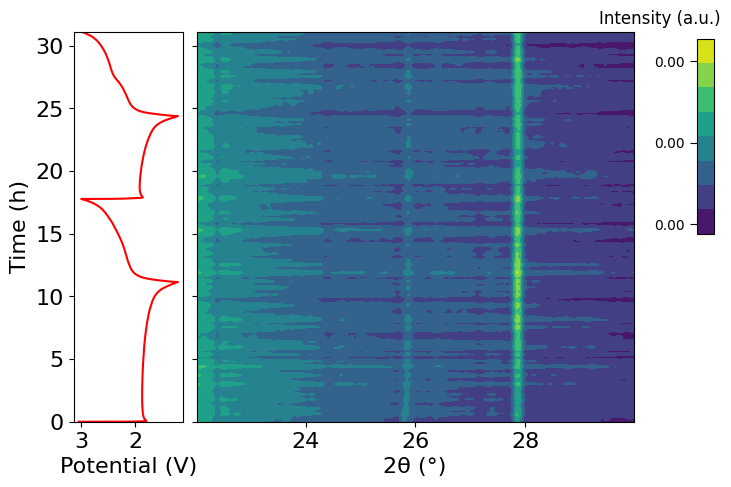

In [54]:
contourplot(
    plot_type='waxs',
    data_normalization='absolute',
    Normalization_file=starting_file, # or starting_file
    data_dictionary=corrected_waxs,
    new_time_dict=all_data['TimeStamps_WAXS'],
    min_limit=sample_settings['WAXS_Min_Limit'],
    max_limit=sample_settings['WAXS_Max_Limit'],
    starting_file=starting_file,
    last_file=last_file,
    elec_df_2=elec_df_2,
    y_axis_mode='time',
    colorbar_position = 'side'
)

Plotting Combined Graph for cycles 1 to 2
Starting file: 3, Discharge file: 105, Last file: 288


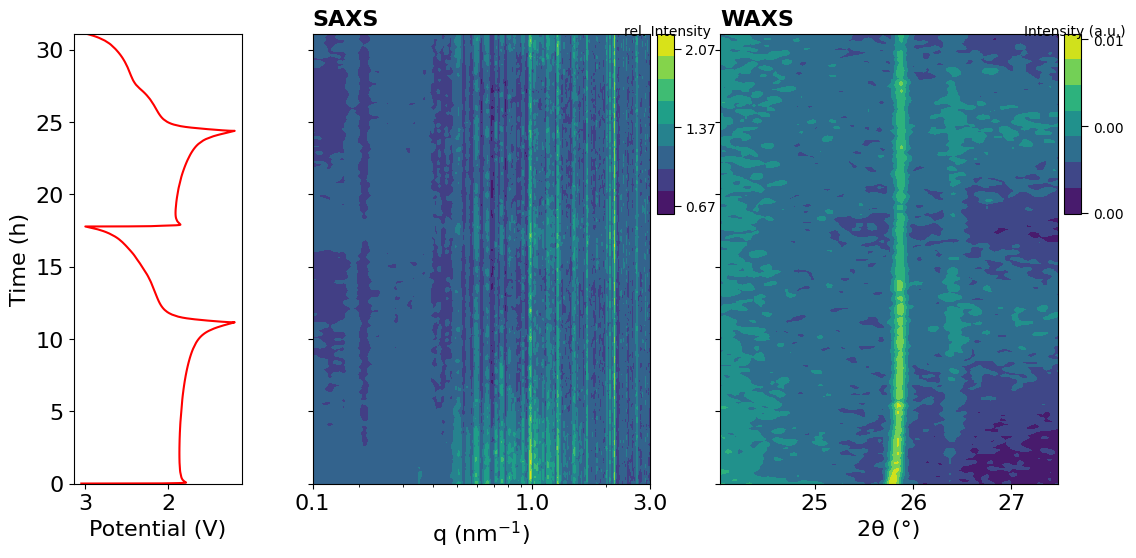

In [65]:
# ---- COMBINED ELECTROCHEMISTRY + SAXS + WAXS PLOT ----
# This single plot shows the electrochemistry curve next to both SAXS and WAXS contour plots
print(f"Plotting Combined Graph for cycles {starting_cycle} to {end_cycle}")
print(f"Starting file: {starting_file}, Discharge file: {discharge_file}, Last file: {last_file}")

# You can choose 'side' or 'bottom' for colorbar_position
combined_contourplot(
    saxs_data_normalization='relative',
    waxs_data_normalization='absolute', # 'relative' or 'absolute'
    saxs_dict=corrected_saxs,
    waxs_dict=all_data['WAXS'],
    new_time_dict=all_data['TimeStamps_SAXS'],
    saxs_min_limit=sample_settings['SAXS_Min_Limit'],
    saxs_max_limit=sample_settings['SAXS_Max_Limit'],
    waxs_min_limit=24,
    waxs_max_limit=27.5,
    Normalization_file_saxs=discharge_file, # Set your normalization file for SAXS
    Normalization_file_waxs=starting_file, # Set your normalization file for WAXS
    colorbar_position='side', # Options: 'side', 'bottom'
    inset_colorbar_inside=True,
    starting_file=starting_file,
    last_file=last_file,
    elec_df_2=elec_df_2,
    y_axis_mode='time', # 'time' or 'capacity'
    # applied_current=0.5, # Required if y_axis_mode='capacity'
    # active_material_mass=2.0, # Required if y_axis_mode='capacity'
    save_plot=False
)

